In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo

In [2]:
from dask.distributed import Client
c = Client()
c

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 9
Total threads: 72,Total memory: 160.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33487,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35538,Total threads: 8
Dashboard: /proxy/46286/status,Memory: 17.78 GiB
Nanny: tcp://127.0.0.1:36929,


2026-04-13 12:41:56,428 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 6088b846fcf794097245703c8ff22b90 initialized by task ('rechunk-merge-rechunk-transfer-dd9a41d18410c0efad8d204ad18efe3b', 4, 0, 0, 5, 0, 0) executed on worker tcp://127.0.0.1:37994
2026-04-13 12:42:09,081 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b6adca9d54e89b5ba899a03084f3cd02 initialized by task ('rechunk-merge-rechunk-transfer-dd9a41d18410c0efad8d204ad18efe3b', 2, 0, 0, 2, 0, 0) executed on worker tcp://127.0.0.1:37743
2026-04-13 12:42:09,170 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cca7bc7145b2e929646110d6781e700d initialized by task ('rechunk-merge-rechunk-transfer-dd9a41d18410c0efad8d204ad18efe3b', 0, 0, 0, 0, 0, 0) executed on worker tcp://127.0.0.1:44958
2026-04-13 12:42:09,190 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle af4537abcffbdd040d100ce830edc5d1 initialized by task ('rechunk-merge-rechunk-transfer-dd9a41d18410c0efad8d204ad18efe3b', 3, 

In [3]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"abyssal_sigma2_depths.zarr"

ds = xr.open_mfdataset(savename).sel(year = slice(None, 2099))

In [4]:
import cmip_basins.cmip6 as cmip6_basins
from cmip_basins.basins import generate_basin_codes
codes = generate_basin_codes(ds, lon="geolon", lat="geolat", persian=True, style="cmip6")
so_ind_pac_mask = codes.isin([1, 3, 5, 10, 11])
so_ind_pac_mask = so_ind_pac_mask.where(so_ind_pac_mask > 0.0)
c_mask = so_ind_pac_mask.where(ds.wet > 0.0)

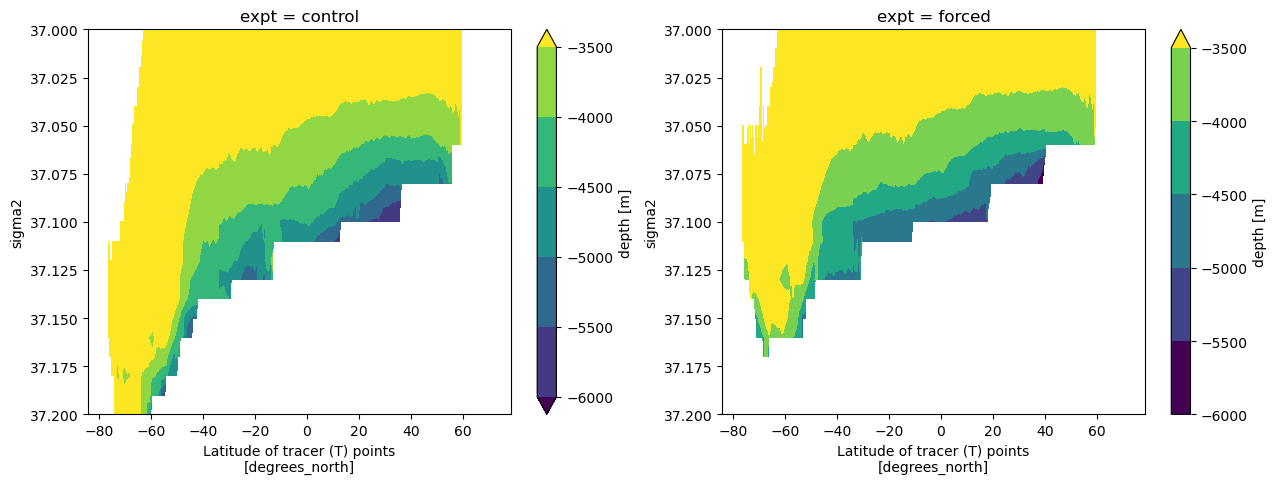

In [13]:
ds_indopac = ds.where(c_mask > 0.0).sel(year = slice(2050, 2099)).mean("year")
ds_indopac = ds_indopac.where(ds_indopac["depth"] < -2000)
ds_indopac.coords["lat"] = ds_indopac["geolat"].mean("xh")

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ds_indopac.sel(expt = "control").mean("xh")["depth"].plot.contourf(ax = ax[0], x = "lat", y = "sigma2", yincrease = False, 
                                                                   levels = np.arange(-6000, -3000, 500))
ds_indopac.sel(expt = "forced").mean("xh")["depth"].plot.contourf(ax = ax[1], x = "lat", y = "sigma2", yincrease = False, 
                                                                   levels = np.arange(-6000, -3000, 500))

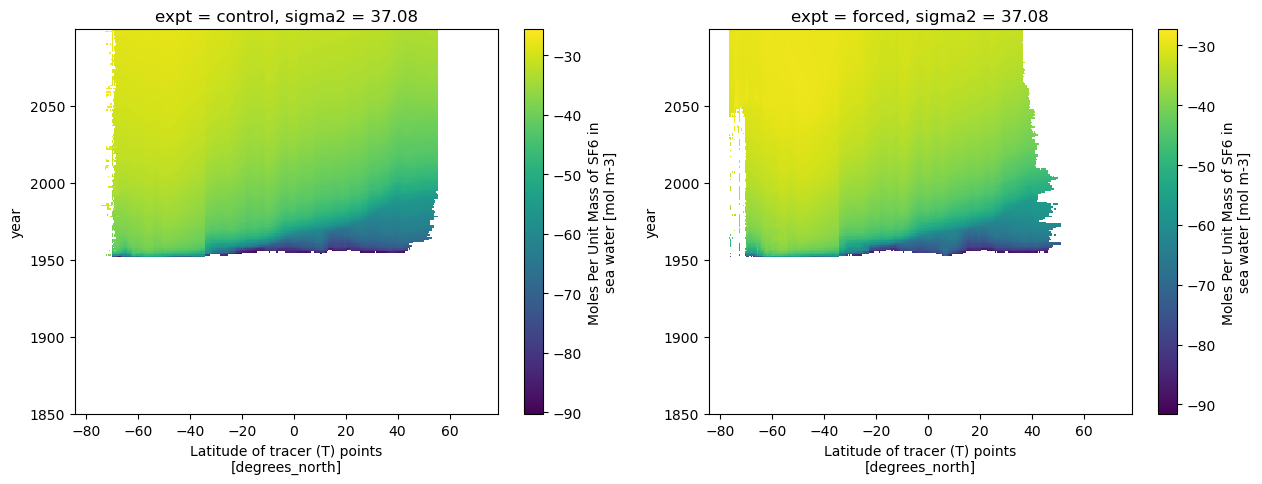

In [43]:
ds_indopac = ds.where(c_mask > 0.0)
ds_indopac = ds_indopac.where(ds_indopac["depth"] < -2000)
ds_indopac = np.log(ds_indopac.mean("xh").sel(sigma2 = 37.08, method = "nearest"))
ds_indopac.coords["lat"] = ds["geolat"].mean("xh")

fig, ax = plt.subplots(1, 2, figsize = (15, 5))
ds_indopac["sf6"].sel(expt = "control").plot(ax = ax[0], x = "lat", y = "year")
ds_indopac["sf6"].sel(expt = "forced").plot(ax = ax[1], x = "lat", y = "year")

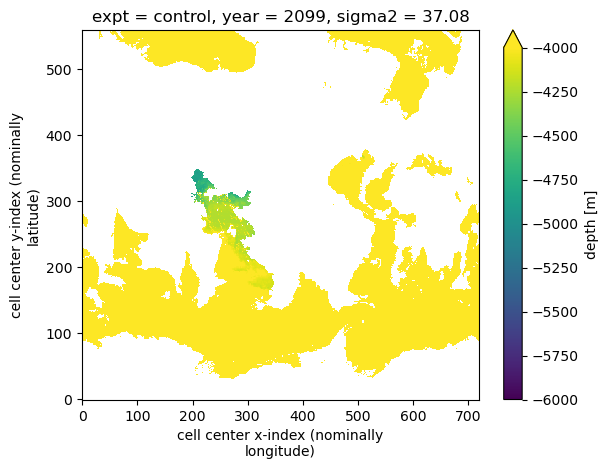

In [165]:
ds_abyssal_depth = ds.interp(sigma2 = 37.08, assume_sorted = False, kwargs={"fill_value": np.nan}).depth
# ds_abyssal_depth = ds_abyssal_depth.where(ds_abyssal_depth.sel(expt = "control").mean("year") < -1000)
ds_abyssal_depth.isel(expt = 0, year = -1).plot(vmin = -6000, vmax = -4000)
ds_abyssal_depth.isel(expt = 0, year = -1).plot.contour(levels = [0, -5000], colors= "white", zorder = 10)

In [166]:
import xarray as xr

def find_constistent_divergence(ts_ds, window_size=25, min_consistent_years=25, fill_nan=True):
    forced_ds = ts_ds.sel(expt="forced")
    control_ds = ts_ds.sel(expt="control")

    if fill_nan:
        forced_ds = forced_ds.chunk({"year": -1}).interpolate_na(
            dim="year", method="linear", fill_value="extrapolate"
        )

    half_window = window_size // 2

    forced_ds = forced_ds.rolling(year=window_size, center=True).mean("year")
    control_ds = control_ds.rolling(year=window_size, center=True).mean("year")

    forced_ds = forced_ds.isel(year=slice(half_window, -half_window))
    control_ds = control_ds.isel(year=slice(half_window, -half_window))

    control_ds = control_ds.sel(year=slice(1850, 1950)).chunk({"year": -1})

    ts_lower = control_ds.quantile(0.01, dim="year", skipna=True)
    ts_upper = control_ds.quantile(0.99, dim="year", skipna=True)

    when_diverged = (forced_ds < ts_lower) | (forced_ds > ts_upper)
    flag = when_diverged.fillna(False).astype(bool)

    diverged_to_end = (
        flag.isel(year=slice(None, None, -1))
            .astype("int8")
            .cumprod("year")
            .astype(bool)
            .isel(year=slice(None, None, -1))
    )

    divergence_start_year = diverged_to_end.idxmax("year").where(diverged_to_end.any("year"))

    seglen = diverged_to_end.sum("year")
    divergence_start_year = xr.where(seglen >= min_consistent_years, divergence_start_year, 1e6)

    return divergence_start_year, seglen

In [177]:
window_size = 25; 
min_consistent_years = 10
divergence_start_year, seglen = find_constistent_divergence(ds_abyssal_depth, 
                                                            window_size = window_size,
                                                           min_consistent_years = min_consistent_years)
divergence_start_year = divergence_start_year.compute()
divergence_start_year = divergence_start_year.where(ds_abyssal_depth.sel(expt = "control").mean("year").notnull()).compute()

Text(0.5, 1.0, 'Detecting years of isopycnal depth divergence on $\\sigma_2 =$ 37.08')

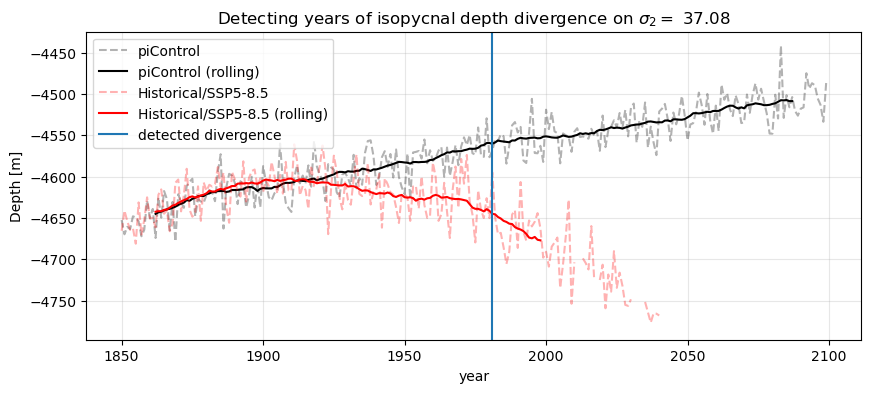

In [178]:
expt_labels = {"control":"piControl", "forced":"Historical/SSP5-8.5"}
expt_colors = {"control":"k", "forced":"r"}
fig, ax = plt.subplots(figsize = (10, 4))

for (i, expt) in enumerate(ds_abyssal_depth.expt.values):
    ds_abyssal_depth.isel(xh = 270, yh = 300).sel(expt = expt).plot(ax = ax, c = expt_colors[expt], label = expt_labels[expt], linestyle = "--", alpha = 0.3)
    ds_abyssal_depth.isel(xh = 270, yh = 300).sel(expt = expt).rolling(year=window_size, center=True).mean().plot(ax = ax, c = expt_colors[expt], label = expt_labels[expt] + " (rolling)")

ax.axvline(divergence_start_year.isel(xh = 270, yh = 300), label = "detected divergence")
ax.set_ylabel("Depth [m]")
ax.grid(alpha = 0.3)
ax.legend()
ax.set_title("Detecting years of isopycnal depth divergence on " + r"$\sigma_2 =$ " + f"{sigma2_value}")

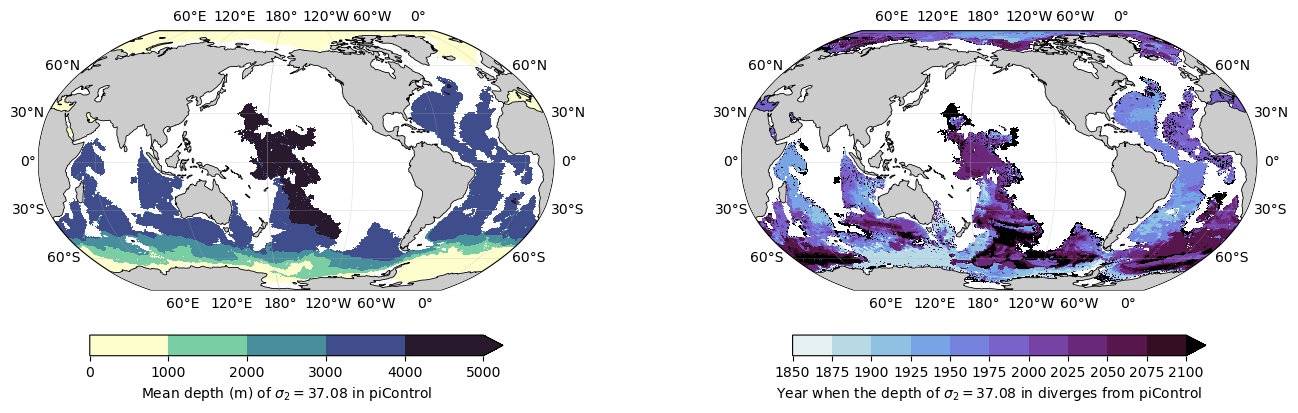

In [179]:
def make_bounds(da, step, vmin = None, vmax = None):
    if vmin is None:
        vmin = float(da.min(skipna=True))
    if vmax is None:
        vmax = float(da.max(skipna=True))
    return np.arange(np.floor(vmin/step)*step, np.ceil(vmax/step)*step + step, step)
    
proj_data = ccrs.PlateCarree()
proj_map  = ccrs.Robinson(central_longitude = -160)

sigma2_value = np.round(ds_abyssal_depth.sigma2.values, decimals = 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), subplot_kw={"projection": proj_map}, constrained_layout=True)

ax = axes[0]; 
background_depth = -ds_abyssal_depth.mean("year").sel(expt = "control").compute()
cmap = cmo.deep
step = 1000
bounds = make_bounds(background_depth, step, vmax = background_depth.quantile(0.975))
cmap = plt.get_cmap(cmap, len(bounds) - 1)
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=False)

pc = ax.pcolormesh(
background_depth["geolon"], background_depth["geolat"], background_depth,
transform=proj_data, cmap=cmap, norm=norm
)
cb0 = fig.colorbar(pc, ax=ax, ticks=bounds, shrink=0.6, pad=0.08, extend = "max", orientation = "horizontal")
cb0.set_label(rf"Mean depth (m) of $\sigma_2 = {sigma2_value}$ in piControl")

ax = axes[1]
cmap = cmo.dense
step = 25
bounds = make_bounds(divergence_start_year, step, vmax = 2100)
cmap = plt.get_cmap(cmap, len(bounds) - 1)
cmap.set_over("black")
norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=False)

pc = ax.pcolormesh(
divergence_start_year["geolon"], divergence_start_year["geolat"], divergence_start_year,
transform=proj_data, cmap=cmap, norm=norm
)

cb0 = fig.colorbar(pc, ax=ax, ticks=bounds, shrink=0.6, pad=0.08, extend = "max", orientation = "horizontal")
cb0.set_label(rf"Year when the depth of $\sigma_2 = {sigma2_value}$ in diverges from piControl")
for ax in axes:
    # ax.set_extent([-200, 200, -90, 65], crs=proj_data)
    ax.add_feature(cfeature.LAND, facecolor="0.8", zorder=3)
    ax.coastlines(linewidth=0.6, zorder=4)
    ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4)